# VietNews Data Profiling (for Summarization)

Notebook này nâng từ data check cơ bản lên **profiling cho bài toán tóm tắt**:

- Kiểm tra schema + null/empty
- Profile độ dài (`chars/tokens/sentences`) cho `title/article/abstract`
- Phân tích quan hệ `article` - `abstract`:
  - `compression_ratio_chars`
  - `compression_ratio_sents`
- Kiểm tra duplication (`guid`, `title`, `article`)
- Kiểm tra noise/format lạ (underscore dày, whitespace lặp, newline, html-like)
- Review outliers + sample đọc tay

Hỗ trợ dữ liệu local `.jsonl` và `.parquet`, chọn được split `train/validation/test`.

> Notebook dùng cùng sentence splitter với backend để thống nhất với API và TF-IDF experiments.

In [13]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path

import pandas as pd

# Add backend root for importing app.services.input.sentence_splitter
cwd = Path.cwd().resolve()
candidates = [cwd / "backend", cwd, cwd.parent / "backend"]
BACKEND_ROOT = next((c for c in candidates if (c / "app").is_dir()), None)
if BACKEND_ROOT is not None and str(BACKEND_ROOT) not in sys.path:
    sys.path.insert(0, str(BACKEND_ROOT))

try:
    from app.services.input.sentence_splitter import split_sentences
    print("Using backend sentence splitter from:", BACKEND_ROOT)
except Exception as exc:
    split_sentences = None
    print("Cannot import backend split_sentences, fallback regex will be used:", exc)

In [14]:
# Chỉnh đường dẫn nếu cần
DATA_DIR = Path("../data/raw/vietnews")

parquet_files = sorted(DATA_DIR.glob("*.parquet"))
jsonl_files = sorted(DATA_DIR.glob("*.jsonl"))

print("DATA_DIR:", DATA_DIR.resolve())
print("parquet files:", [p.name for p in parquet_files])
print("jsonl files:", [p.name for p in jsonl_files])

DATA_DIR: C:\Users\OS\OneDrive\Desktop\Text_Summarization\data\raw\vietnews
parquet files: ['data__test-00000-of-00001-123f98d55067eb7b.parquet', 'data__train-00000-of-00001-84acb79f6c6547a5.parquet', 'data__validation-00000-of-00001-210cc51bf3cdb90f.parquet']
jsonl files: ['test.jsonl', 'train.jsonl', 'validation.jsonl']


In [15]:
def load_jsonl(path: Path, max_rows: int | None = None) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
            if max_rows is not None and len(rows) >= max_rows:
                break
    return pd.DataFrame(rows)


def load_any(path: Path, max_rows: int | None = None) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        try:
            df = pd.read_parquet(path)
        except Exception as exc:
            raise RuntimeError(f"read_parquet failed for {path.name}: {exc}") from exc
        if max_rows is not None:
            return df.head(max_rows).copy()
        return df
    if suffix == ".jsonl":
        return load_jsonl(path, max_rows=max_rows)
    raise ValueError(f"Unsupported file type: {suffix}")

In [16]:
# Chọn split + định dạng ưu tiên
TARGET_SPLIT = "train"  # train / validation / test
prefer_parquet = False   # True nếu env đọc parquet ổn
MAX_ROWS = 20000         # None để đọc toàn bộ


def _pick_by_split(files: list[Path], split: str) -> list[Path]:
    hit = [p for p in files if split in p.name.lower()]
    return hit or files


primary_files = _pick_by_split(parquet_files if prefer_parquet else jsonl_files, TARGET_SPLIT)
fallback_files = _pick_by_split(jsonl_files if prefer_parquet else parquet_files, TARGET_SPLIT)

if not primary_files and not fallback_files:
    raise FileNotFoundError("Không tìm thấy parquet/jsonl trong data/raw/vietnews")

last_error = None
for source_path in primary_files + fallback_files:
    try:
        df = load_any(source_path, max_rows=MAX_ROWS)
        print(f"Loaded split={TARGET_SPLIT} from {source_path.name} | rows={len(df)}")
        print("Columns:", list(df.columns))
        break
    except Exception as exc:
        last_error = exc
        print(f"Skip {source_path.name}: {exc}")
else:
    raise RuntimeError(f"Không load được dữ liệu từ parquet/jsonl. Lỗi cuối: {last_error}")

Loaded: train.jsonl | rows: 20000
Columns: ['guid', 'title', 'abstract', 'article']


In [17]:
required_cols = ["title", "article", "abstract"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    print("Thiếu cột:", missing)
else:
    print("Schema OK: có đủ title/article/abstract")

Schema OK: có đủ title/article/abstract


In [18]:
def is_empty(v) -> bool:
    if pd.isna(v):
        return True
    return not str(v).strip()


check_cols = [c for c in ["title", "article", "abstract"] if c in df.columns]
stats = []
for c in check_cols:
    empty_count = int(df[c].apply(is_empty).sum())
    stats.append(
        {
            "column": c,
            "empty_count": empty_count,
            "empty_ratio": empty_count / max(1, len(df)),
        }
    )
pd.DataFrame(stats)

,column,empty_count,empty_ratio
0,title,0,0.0
1,article,0,0.0
2,abstract,0,0.0


In [19]:
sentence_sep = re.compile(r"(?<=[.!?…])\s+|\n+")


def count_tokens(text: str) -> int:
    return len(re.findall(r"\w+", text, flags=re.UNICODE))


def count_sentences(text: str) -> int:
    if split_sentences is not None:
        try:
            return len(split_sentences(text))
        except Exception:
            pass
    parts = [p.strip() for p in sentence_sep.split(text) if p.strip()]
    return len(parts)


for col in ["title", "article", "abstract"]:
    if col not in df.columns:
        continue
    s = df[col].fillna("").astype(str)
    df[f"{col}_chars"] = s.str.len()
    df[f"{col}_tokens"] = s.apply(count_tokens)
    if col in ["article", "abstract"]:
        df[f"{col}_sents"] = s.apply(count_sentences)

# Profiling riêng cho summarization: độ nén reference vs source
if {"article_chars", "abstract_chars"}.issubset(df.columns):
    df["compression_ratio_chars"] = df["abstract_chars"] / df["article_chars"].clip(lower=1)
if {"article_sents", "abstract_sents"}.issubset(df.columns):
    df["compression_ratio_sents"] = df["abstract_sents"] / df["article_sents"].clip(lower=1)

metric_cols = [c for c in df.columns if c.endswith(("_chars", "_tokens", "_sents"))]
display(df[metric_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

ratio_cols = [c for c in ["compression_ratio_chars", "compression_ratio_sents"] if c in df.columns]
if ratio_cols:
    print("\nCompression ratio stats:")
    display(df[ratio_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

,count,mean,std,min,50%,90%,95%,99%,max
title_chars,20000.0,62.92815,14.883648,9.0,62.0,81.0,88.0,106.00,190.0
title_tokens,20000.0,10.51360,2.913098,1.0,10.0,14.0,15.0,20.00,33.0
article_chars,20000.0,2315.75360,1105.806323,458.0,2084.0,3874.0,4457.0,5495.03,12135.0
article_tokens,20000.0,374.46740,180.715676,69.0,335.0,629.0,722.0,900.01,1862.0
article_sents,20000.0,19.75575,9.918589,4.0,17.5,34.0,39.0,49.00,102.0
abstract_chars,20000.0,174.35820,42.988532,46.0,172.0,229.0,244.0,291.00,658.0
abstract_tokens,20000.0,28.40130,7.942482,6.0,28.0,38.0,42.0,54.00,109.0
abstract_sents,20000.0,1.47865,0.724479,1.0,1.0,2.0,3.0,4.00,9.0


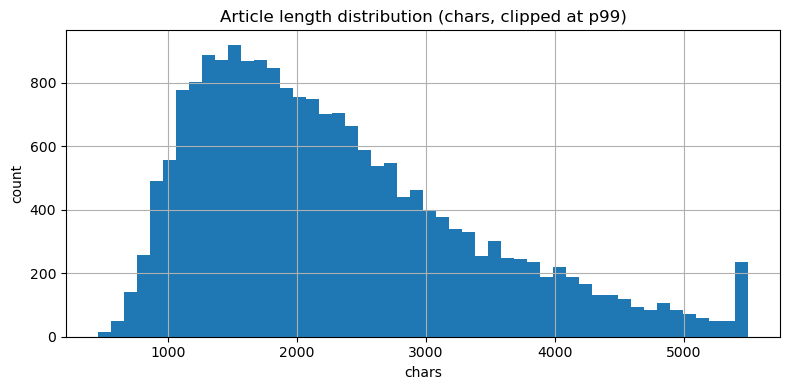

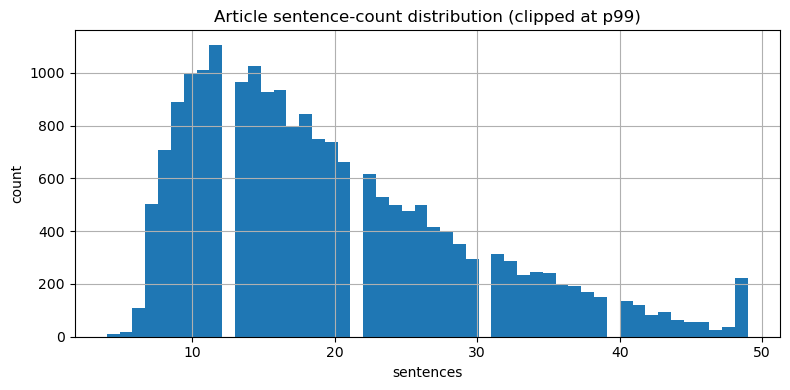

In [20]:
import matplotlib.pyplot as plt

if "article_chars" in df.columns:
    plt.figure(figsize=(8, 4))
    df["article_chars"].clip(upper=df["article_chars"].quantile(0.99)).hist(bins=50)
    plt.title("Article length distribution (chars, clipped at p99)")
    plt.xlabel("chars")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

if "article_sents" in df.columns:
    plt.figure(figsize=(8, 4))
    df["article_sents"].clip(upper=df["article_sents"].quantile(0.99)).hist(bins=50)
    plt.title("Article sentence-count distribution (clipped at p99)")
    plt.xlabel("sentences")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

if "compression_ratio_chars" in df.columns:
    plt.figure(figsize=(8, 4))
    df["compression_ratio_chars"].clip(upper=df["compression_ratio_chars"].quantile(0.99)).hist(bins=50)
    plt.title("Compression ratio (abstract_chars / article_chars)")
    plt.xlabel("ratio")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

if "compression_ratio_sents" in df.columns:
    plt.figure(figsize=(8, 4))
    df["compression_ratio_sents"].clip(upper=df["compression_ratio_sents"].quantile(0.99)).hist(bins=50)
    plt.title("Compression ratio (abstract_sents / article_sents)")
    plt.xlabel("ratio")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

In [21]:
# Duplication + noise checks cho summarization

# 1) Duplication
dup_stats = {}
for col in ["guid", "title", "article"]:
    if col in df.columns:
        dup_stats[f"dup_{col}"] = int(df[col].duplicated().sum())

display(pd.DataFrame([dup_stats]))

# 2) Noise / format lạ
article_text = df["article"].fillna("").astype(str) if "article" in df.columns else pd.Series([], dtype=str)
abstract_text = df["abstract"].fillna("").astype(str) if "abstract" in df.columns else pd.Series([], dtype=str)

noise_stats = {
    "article_has_newline": int(article_text.str.contains(r"\n", regex=True).sum()),
    "abstract_has_newline": int(abstract_text.str.contains(r"\n", regex=True).sum()),
    "article_many_underscores(>=10)": int(article_text.str.count(r"_").ge(10).sum()),
    "abstract_many_underscores(>=5)": int(abstract_text.str.count(r"_").ge(5).sum()),
    "article_multi_space": int(article_text.str.contains(r"\s{2,}", regex=True).sum()),
    "abstract_multi_space": int(abstract_text.str.contains(r"\s{2,}", regex=True).sum()),
    "article_html_like": int(article_text.str.contains(r"<[^>]+>", regex=True).sum()),
    "abstract_html_like": int(abstract_text.str.contains(r"<[^>]+>", regex=True).sum()),
}
display(pd.DataFrame([noise_stats]))

# 3) Bản ghi bất thường để review nhanh
bad_short = df[df.get("article_chars", 0) < 200].head(20)
bad_long = df[df.get("article_chars", 0) > 8000].head(20)

print("short articles (<200 chars):", len(bad_short))
print("long articles (>8000 chars):", len(bad_long))

display(bad_short[[c for c in ["guid", "title", "article", "abstract", "article_chars"] if c in bad_short.columns]].head(5))
display(bad_long[[c for c in ["guid", "title", "article", "abstract", "article_chars"] if c in bad_long.columns]].head(5))

short articles (<200 chars): 0
long articles (>8000 chars): 16


,title,article,abstract,article_chars


,title,article,abstract,article_chars
3124,"Công_bố kết_luận , chuyển hồ_sơ vụ Út ' ' trọc...","Ngày 11/4 , Thanh_tra Chính_phủ thông_tin về K...",Thanh_tra Chính_phủ kiến_nghị Thủ_tướng chỉ_đạ...,8835
10263,Việt_Nam - cơ_hội bứt_phá về công_nghệ,Thông_tin GS toán_học nổi_tiếng Vũ_Hà_Văn sẽ đ...,Thông_tin GS toán_học nổi_tiếng Vũ_Hà_Văn sẽ đ...,11633
10405,Tổng_Bí_thư Nguyễn_Phú_Trọng hội_đàm với Tổng_...,Tổng_Bí_thư Nguyễn_Phú_Trọng nhiệt_liệt hoan_n...,"Chiều 12-11 , tại trụ_sở Trung_ương Đảng , Tổn...",11869
11029,Chủ_tịch UBND TP. HCM xin_lỗi người_dân Thủ_Thiêm,"Phát_biểu kết lại buổi tiếp người_dân khu 4,3 ...","Sau khi lắng_nghe và trao_đổi với người_dân , ...",12135
12593,Kiến_nghị Thủ_tướng ' dẹp loạn ' danh_hiệu ngh...,"Bộ Văn_hoá , thể_thao và du_lịch kiến_nghị Thủ...","Bộ Văn_hoá , thể_thao và du_lịch vừa có văn_bả...",9414


In [22]:
# Sample ngẫu nhiên để đọc tay
sample_n = 5
sample_df = df.sample(n=min(sample_n, len(df)), random_state=42)
for i, row in enumerate(sample_df.to_dict(orient="records"), start=1):
    print(f"\n=== SAMPLE {i} ===")
    print("TITLE:", str(row.get("title", ""))[:200])
    print("ABSTRACT:", str(row.get("abstract", ""))[:300])
    print("ARTICLE:", str(row.get("article", ""))[:600])


=== SAMPLE 1 ===
TITLE: Kiểm điểm ngay vụ ' thôn chặn xe đám_cưới ... đòi nợ tiền làm đường '
ABSTRACT: Chiều 30-10 , Huyện ủy Tây Hòa ( Phú Yên ) cho biết đã yêu_cầu Đảng ủy , UBND xã Sơn Thành Tây chỉ đạo kiểm điểm , rút kinh nghiệm ngay với bí thư chi bộ thôn và trưởng thôn Sơn_Tây về vụ " chặn xe đám_cưới " .
ARTICLE: Liên_quan đến vụ " Thôn chặn xe đám cưới … đòi nợ tiền làm đường " , chiều 30-10 , ông Nguyễn Phít , phó bí thư thường trực Huyện ủy Tây Hòa ( Phú Yên ) , cho biết ngay sau khi biết tin đã yêu_cầu Đảng ủy , UBND xã Sơn Thành Tây chỉ đạo kiểm điểm , rút kinh nghiệm ngay với bí thư chi bộ thôn và trưởng thôn Sơn_Tây . Ông Nguyễn Phít cho biết ông đã điện thoại cho bí thư Đảng ủy và chủ tịch UBND xã Sơn Thành Tây , yêu cầu cử lãnh đạo đến ngay nhà bà Nguyễn Thị Thu để trao đổi nhằm chia sẻ , thông cảm nhau . " Tôi cũng yêu cầu xa

=== SAMPLE 2 ===
TITLE: Khởi_tố sáu đối_tượng tron

In [23]:
# Lưu báo cáo tóm tắt để tham chiếu
report_dir = Path("./results")
report_dir.mkdir(parents=True, exist_ok=True)

summary = {
    "source_file": str(source_path),
    "target_split": TARGET_SPLIT,
    "rows_loaded": int(len(df)),
    "columns": list(df.columns),
}

for col in ["title", "article", "abstract"]:
    if col in df.columns:
        s = df[col].fillna("").astype(str)
        summary[f"{col}_empty_ratio"] = float((s.str.strip() == "").mean())

for col in ["guid", "title", "article"]:
    if col in df.columns:
        summary[f"dup_{col}"] = int(df[col].duplicated().sum())

for col in ["compression_ratio_chars", "compression_ratio_sents"]:
    if col in df.columns:
        summary[f"{col}_mean"] = float(df[col].mean())
        summary[f"{col}_p50"] = float(df[col].quantile(0.50))
        summary[f"{col}_p90"] = float(df[col].quantile(0.90))

out_path = report_dir / f"vietnews_data_check_summary_{TARGET_SPLIT}.json"
out_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out_path.resolve())

Saved: C:\Users\OS\OneDrive\Desktop\Text_Summarization\notebooks\results\vietnews_data_check_summary.json
